# 02 · Mood Label Creation

> **Goal:** clean the raw Spotify Tracks dataset and derive a `mood` label for every track using the **Arousal–Valence** model from music psychology.

| Quadrant | `valence` | `energy` | Mood label |
|---|---|---|---|
| High arousal / Positive | ≥ 0.5 | ≥ 0.5 | `happy` |
| High arousal / Negative | < 0.5 | ≥ 0.5 | `energetic` |
| Low arousal / Positive | ≥ 0.5 | < 0.5 | `chill` |
| Low arousal / Negative | < 0.5 | < 0.5 | `sad` |

**Pipeline**
1. Load raw CSV
2. Clean (drop junk columns, NaNs, duplicate `track_id`s)
3. Assign mood labels
4. Validate class balance
5. Visualise distribution
6. Export processed CSV

## 1 · Configuration

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

RAW_PATH       = Path("../data/raw/spotify_tracks_raw.csv").resolve()
PROCESSED_PATH = Path("../data/processed/spotify_tracks_mood_clean.csv").resolve()
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

# Arousal-Valence thresholds
VALENCE_THRESHOLD = 0.5
ENERGY_THRESHOLD  = 0.5

# Feature columns to keep in the final dataset
KEEP_COLS = [
    "track_id", "track_name", "artists", "album_name", "track_genre",
    "popularity", "danceability", "energy", "loudness",
    "acousticness", "instrumentalness", "valence", "tempo",
]

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 30)


## 2 · Load Raw Data

In [4]:
df_raw = pd.read_csv(RAW_PATH, dtype_backend="numpy_nullable", encoding="utf-8")

print(f"Shape  : {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(3)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


## 3 · Cleaning Pipeline

Steps applied in a single method chain:
- Drop the anonymous index column (`Unnamed: 0`) injected by Kaggle.
- Keep only the columns relevant to modelling.
- Drop rows with any `NaN` in the feature columns.
- Deduplicate by `track_id` — the same song may appear across multiple genres; we keep the first occurrence.

In [10]:
df = (
    df_raw
    .drop(columns=[c for c in df_raw.columns if c.startswith("Unnamed")], errors="ignore")
    .loc[:, KEEP_COLS]
    .dropna(subset=KEEP_COLS)
    .drop_duplicates(subset="track_id", keep="first")
    .reset_index(drop=True)
)

removed = df_raw.shape[0] - df.shape[0]
print(f"Raw rows      : {df_raw.shape[0]:>7,}")
print(f"Clean rows    : {df.shape[0]:>7,}  ({removed:,} removed)")
print(f"Remaining NaNs: {df.isna().sum().sum()}")
df.head(3)

,track_id,track_name,artists,album_name,track_genre,popularity,danceability,energy,loudness,acousticness,instrumentalness,valence,tempo
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,Comedy,acoustic,73,0.676,0.461,-6.746,0.0322,0.000001,0.715,87.917
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,55,0.420,0.166,-17.235,0.9240,0.000006,0.267,77.489
2,1iJBSr7s7jYXzM8EGcbK5b,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,57,0.438,0.359,-9.734,0.2100,0.000000,0.120,76.332


## 4 · Mood Label Assignment

We use `numpy.select` for a fully **vectorised** assignment.

In [19]:
MOOD_LOOKUP = np.array(["sad", "energetic", "chill", "happy"])

df["mood"] = pd.Categorical(
    MOOD_LOOKUP[
        (df["valence"] >= VALENCE_THRESHOLD).astype(int) * 2
        + (df["energy"] >= ENERGY_THRESHOLD).astype(int)
    ]
)

print("Mood distribution:")
display(
    df["mood"]
    .value_counts()
    .rename_axis("mood")
    .to_frame("count")
    .assign(pct=lambda x: (x["count"] / len(df) * 100).round(2).astype(str) + " %")
    .style.bar(subset=["count"], color="#11334F")
)

,count,pct
mood,,
happy,33220,37.02 %
energetic,30211,33.67 %
sad,19030,21.21 %
chill,7279,8.11 %


## 5 · Validation

Quick sanity-checks to catch label assignment bugs before exporting.

In [13]:
VALID_MOODS = {"happy", "energetic", "chill", "sad"}

assert set(df["mood"].unique()) == VALID_MOODS, "Unexpected mood values found!"
assert df["mood"].isna().sum() == 0,            "NaN moods detected!"
assert df["track_id"].is_unique,                "Duplicate track_ids remain!"

# Spot-check: a high-valence, high-energy track must be 'happy'
sample_happy = df.query("valence >= @VALENCE_THRESHOLD and energy >= @ENERGY_THRESHOLD").iloc[0]
assert sample_happy["mood"] == "happy"

print("✅ All assertions passed.")

✅ All assertions passed.


## 6 · Distribution Visualisation

Two complementary views: **bar chart** of class counts and a **scatter plot** of the Arousal–Valence space coloured by mood.

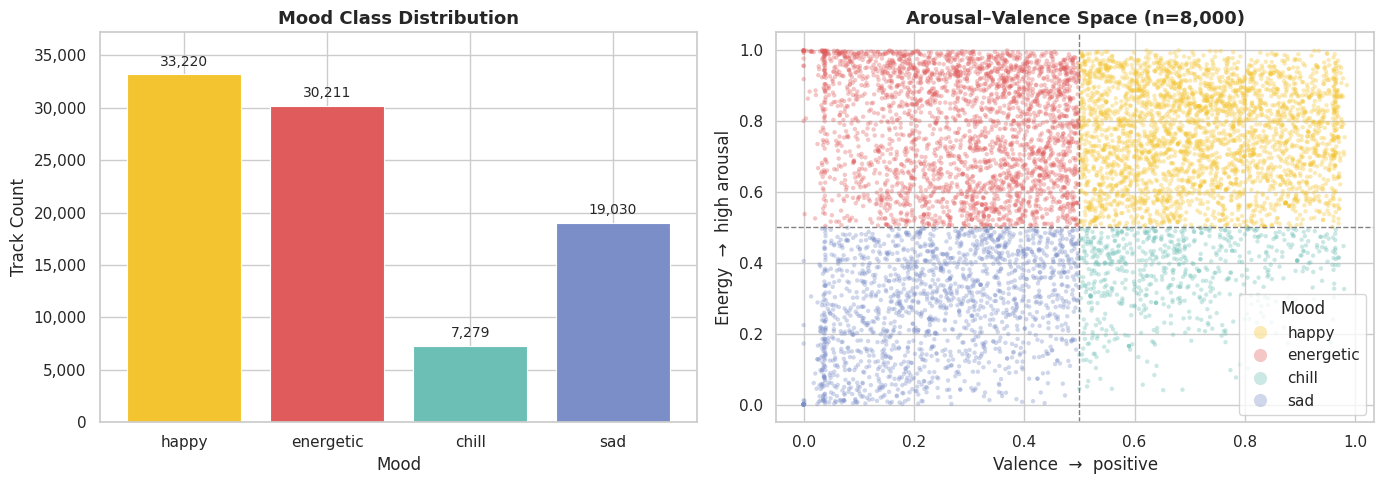

In [20]:
MOOD_ORDER   = ["happy", "energetic", "chill", "sad"]
MOOD_PALETTE = {"happy": "#F4C430", "energetic": "#E05C5C", "chill": "#6BBFB5", "sad": "#7B8EC8"}

def _plot_bar(ax, counts):
    bars = ax.bar(
        counts.index, counts.values,
        color=[MOOD_PALETTE[m] for m in counts.index],
        edgecolor="white", linewidth=0.8,
    )
    ax.bar_label(bars, labels=[f"{v:,}" for v in counts.values], padding=4, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_ylim(0, counts.max() * 1.12)
    ax.set(title="Mood Class Distribution", xlabel="Mood", ylabel="Track Count")

def _plot_scatter(ax, sample):
    sns.scatterplot(
        data=sample, x="valence", y="energy",
        hue="mood", hue_order=MOOD_ORDER, palette=MOOD_PALETTE,
        alpha=0.35, s=10, linewidth=0, ax=ax,
    )
    ax.axvline(VALENCE_THRESHOLD, color="grey", lw=1, ls="--")
    ax.axhline(ENERGY_THRESHOLD,  color="grey", lw=1, ls="--")
    ax.legend(title="Mood", markerscale=3, framealpha=0.8)
    ax.set(title="Arousal–Valence Space (n=8,000)",
           xlabel="Valence  →  positive",
           ylabel="Energy  →  high arousal")

# Render
fig, (ax_bar, ax_scatter) = plt.subplots(1, 2, figsize=(14, 5))

_plot_bar(ax_bar, df["mood"].value_counts().reindex(MOOD_ORDER))
_plot_scatter(ax_scatter, df.sample(min(8_000, len(df)), random_state=42))

for ax in (ax_bar, ax_scatter):
    ax.title.set(fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../data/processed/mood_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 · Export Processed Dataset

In [16]:
df.to_csv(PROCESSED_PATH, index=False)

print(f"Saved  → {PROCESSED_PATH}")
print(f"Rows   : {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

Saved  → /home/viperdb3/PycharmProjects/moodify/data/processed/spotify_tracks_mood_clean.csv
Rows   : 89,740
Columns: ['track_id', 'track_name', 'artists', 'album_name', 'track_genre', 'popularity', 'danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'mood']
